# Polar Lights Notebook Interface

Use this notebook as a visual entry point:
- **Section 1**: Browse committed, precomputed reference plots (no pipeline execution).
- **Section 2**: Run the real project pipeline with your own parameters.

## Examples (precomputed results)

### Example: Aurora observations plot

**Parameters used:**

- `date_str = "2025-11-12"`
- `ionosonde_code = None`
- `cosmic_station_codes = None`

**Description:**

This placeholder image represents an aurora-related output generated by the project pipeline.

**Data sources:**

- spaceweatherlive.com

**Generated by:**

- `app.pipeline.main_pipeline.run_main_pipeline`

**Image:**

_Image placeholder: add a committed precomputed image path in `notebooks/graph_examples/`._

---

### Example: ROTI reference plot

**Parameters used:**

- `date_str = "2025-11-12"`
- `ionosonde_code = None`
- `cosmic_station_codes = ["YELL", "KIRU"]`

**Description:**

This placeholder image represents a ROTI-oriented output produced by the pipeline.

**Data sources:**

- SIMuRG services and upstream GNSS-derived products

**Generated by:**

- `app.pipeline.roti_pipeline.run_roti_pipeline`

**Image:**

_Image placeholder: add a committed precomputed image path in `notebooks/graph_examples/`._

## Run with your parameters

### Set up environment

In [1]:
# --- Notebook bootstrap: works locally + in Colab ---
from pathlib import Path
import os, sys

def _find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "app").exists():
            return parent
    return p

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

# If running in Colab and repo files aren't present, clone automatically
if IN_COLAB and not (Path.cwd() / "app").exists():
    import subprocess
    if not Path("Polar-lights").exists():
        subprocess.check_call([
            "git", "clone", "-b", "main",
            "https://github.com/Yuri-ga1/Polar-lights.git"
        ])
    os.chdir("Polar-lights")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Install deps in Colab (safe to re-run)
if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "poetry"])
    subprocess.check_call(["poetry", "config", "virtualenvs.create", "false"])
    subprocess.check_call(["poetry", "install", "--no-interaction", "--no-ansi"])

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Project root: E:\git_reps\Polar-lights
Python: e:\Programming\miniconda\envs\polar_lights\python.exe


In [2]:
from app.visualization.plot_settings import set_plt_def_params
set_plt_def_params()

### Run all

In [ ]:
# Required params that you must fill
date_str = "2025-11-12"  # required


# Required parameters that do not need to be changed
download_base_dir = "files"  # base dir for downloaded files
plots_base_dir = "results"  # base dir for generated plots


# Optional parameters for more flexible configuration
ionosonde_code = None  # optional
cosmic_station_codes = None  # optional list
email = None  # optional

In [ ]:
from pathlib import Path
import logging

from app.pipeline.main_pipeline import MainPipelineConfig, run_main_pipeline
from app.visualization.plot_settings import set_plt_def_params

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(threadName)s: %(message)s')
set_plt_def_params()

BASE_DIR = Path.cwd().parent
download_dir = BASE_DIR / Path(download_base_dir)
plots_dir = BASE_DIR / Path(plots_base_dir)
download_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

config = MainPipelineConfig(
    date_str=date_str,
    download_base_dir=download_dir,
    plots_base_dir=plots_dir,
    ionosonde_code=ionosonde_code,
    cosmic_station_codes=cosmic_station_codes,
    simurg_email=email,
)

run_main_pipeline(config)
print(f'Pipeline run complete. Download directory: {download_dir.resolve()}')
print(f'Pipeline run complete. Results directory: {plots_dir.resolve()}')


### Run Adjusted TEC Map

In [ ]:
# 1) Parameters for Adjusted TEC map
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"
email = None  # optional


In [ ]:
# 2) Download Adjusted TEC data
from pathlib import Path
import os

from app.simurg.simurg_client import SimurgClient
from app.simurg.simurg_downloader import AdjustedTecDownloader
from app.simurg.simurg_processor import DataProduct, SimurgProcessor

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
simurg_dir = download_dir / "simurg"
simurg_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

simurg_client = SimurgClient(email=email or "Storm_Plotter_Jupyter_Notebook@gmail.com")
AdjustedTecDownloader(client=simurg_client, out_dir=str(simurg_dir)).download(date_str)
adjusted_tec_data = SimurgProcessor(folder_path=str(simurg_dir)).load(date_str, product_type=DataProduct.TEC_ADJUSTED)
print(f"Adjusted TEC data points loaded: {len(adjusted_tec_data)}")


In [ ]:
# 3) Plot Adjusted TEC map
from datetime import datetime
from app.visualization.roti_plotter import plot_map

def pick_plot_times(data: dict[datetime, object], max_plots: int = 4) -> list[datetime]:
    if not data:
        return []
    sorted_times = sorted(data.keys())
    if len(sorted_times) <= max_plots:
        return sorted_times
    step = max(1, len(sorted_times) // max_plots)
    selected = sorted_times[::step][:max_plots]
    if sorted_times[-1] not in selected:
        selected[-1] = sorted_times[-1]
    return selected

plot_map(data=adjusted_tec_data, plot_times=pick_plot_times(adjusted_tec_data), product_type="tec_adjusted", save_dir=str(plots_dir))
print(f"Adjusted TEC maps saved to: {plots_dir.resolve()}")


### Run ROTI Map

In [ ]:
# 1) Parameters for ROTI map
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"
email = None  # optional


In [ ]:
# 2) Download ROTI data
from pathlib import Path
from datetime import datetime, timedelta

from app.simurg.simurg_client import SimurgClient
from app.simurg.simurg_downloader import RotiDownloader
from app.simurg.simurg_processor import DataProduct, SimurgProcessor

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
simurg_dir = download_dir / "simurg"
simurg_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

simurg_client = SimurgClient(email=email or "Storm_Plotter_Jupyter_Notebook@gmail.com")
RotiDownloader(client=simurg_client, out_dir=str(simurg_dir)).download(date_str)

target_date = datetime.strptime(date_str, "%Y-%m-%d")
file_start_date = (target_date - timedelta(days=1)).date()
roti_data = SimurgProcessor(folder_path=str(simurg_dir)).load(file_start_date, product_type=DataProduct.ROTI)
print(f"ROTI data points loaded: {len(roti_data)}")


In [ ]:
# 3) Plot ROTI map
from datetime import datetime
from app.visualization.roti_plotter import plot_map

def pick_plot_times(data: dict[datetime, object], max_plots: int = 4) -> list[datetime]:
    if not data:
        return []
    sorted_times = sorted(data.keys())
    if len(sorted_times) <= max_plots:
        return sorted_times
    step = max(1, len(sorted_times) // max_plots)
    selected = sorted_times[::step][:max_plots]
    if sorted_times[-1] not in selected:
        selected[-1] = sorted_times[-1]
    return selected

plot_map(data=roti_data, plot_times=pick_plot_times(roti_data), product_type="roti", save_dir=str(plots_dir))
print(f"ROTI maps saved to: {plots_dir.resolve()}")


### Run ROTI Keogram

In [ ]:
# 1) Parameters for ROTI keogram
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"
email = None  # optional


In [ ]:
# 2) Download ROTI data
from pathlib import Path
from datetime import datetime, timedelta

from app.simurg.simurg_client import SimurgClient
from app.simurg.simurg_downloader import RotiDownloader
from app.simurg.simurg_processor import DataProduct, SimurgProcessor

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
simurg_dir = download_dir / "simurg"
simurg_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

simurg_client = SimurgClient(email=email or "Storm_Plotter_Jupyter_Notebook@gmail.com")
RotiDownloader(client=simurg_client, out_dir=str(simurg_dir)).download(date_str)

target_date = datetime.strptime(date_str, "%Y-%m-%d")
file_start_date = (target_date - timedelta(days=1)).date()
roti_data = SimurgProcessor(folder_path=str(simurg_dir)).load(file_start_date, product_type=DataProduct.ROTI)
print(f"ROTI data points loaded: {len(roti_data)}")


In [ ]:
# 3) Plot ROTI keogram
from app.visualization.keogram_plotter import plot_keogram

keys = list(roti_data.keys())
day_start = min(keys)
day_finish = max(keys)
plot_keogram(data=roti_data, day_start=day_start, day_finish=day_finish, save_dir=str(plots_dir))
print(f"ROTI keogram saved to: {plots_dir.resolve()}")


### Run Aurora Observations

In [17]:
# 1) Parameters for aurora observations plot
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"
plot_time = datetime(2025, 11, 12, 2, 0)

In [18]:
# 2) Download aurora observations data
from pathlib import Path
from datetime import datetime, timedelta

from app.pipeline.observation_pipeline import (
    collect_observation_links,
    load_observations_from_csv,
    parse_and_save_observations
)
from app.storage.hdf5_storage import ObservationHDF5Storage

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
h5_path = os.path.join(download_dir, "spaceweather_observations.h5")
csv_path = os.path.join(download_dir, "aurora_data.csv")

observations: list[dict[str, str]] = []
storage = ObservationHDF5Storage(h5_path)

date_iso = date_str
date_str = date_str.replace('-', '/')

cached_rows = load_observations_from_csv(csv_path, date_iso)
if cached_rows:
    observations.extend(cached_rows)

if storage.has_date(date_iso):
    observations.extend(
        parse_and_save_observations(
            h5_path,
            csv_path,
            dates=[date_iso],
        )
    )

collect_observation_links(date_str, h5_path)
observations.extend(
    parse_and_save_observations(
        h5_path,
        csv_path,
        dates=[date_iso],
    )
)

2025/11/12: найдено 43 наблюдений


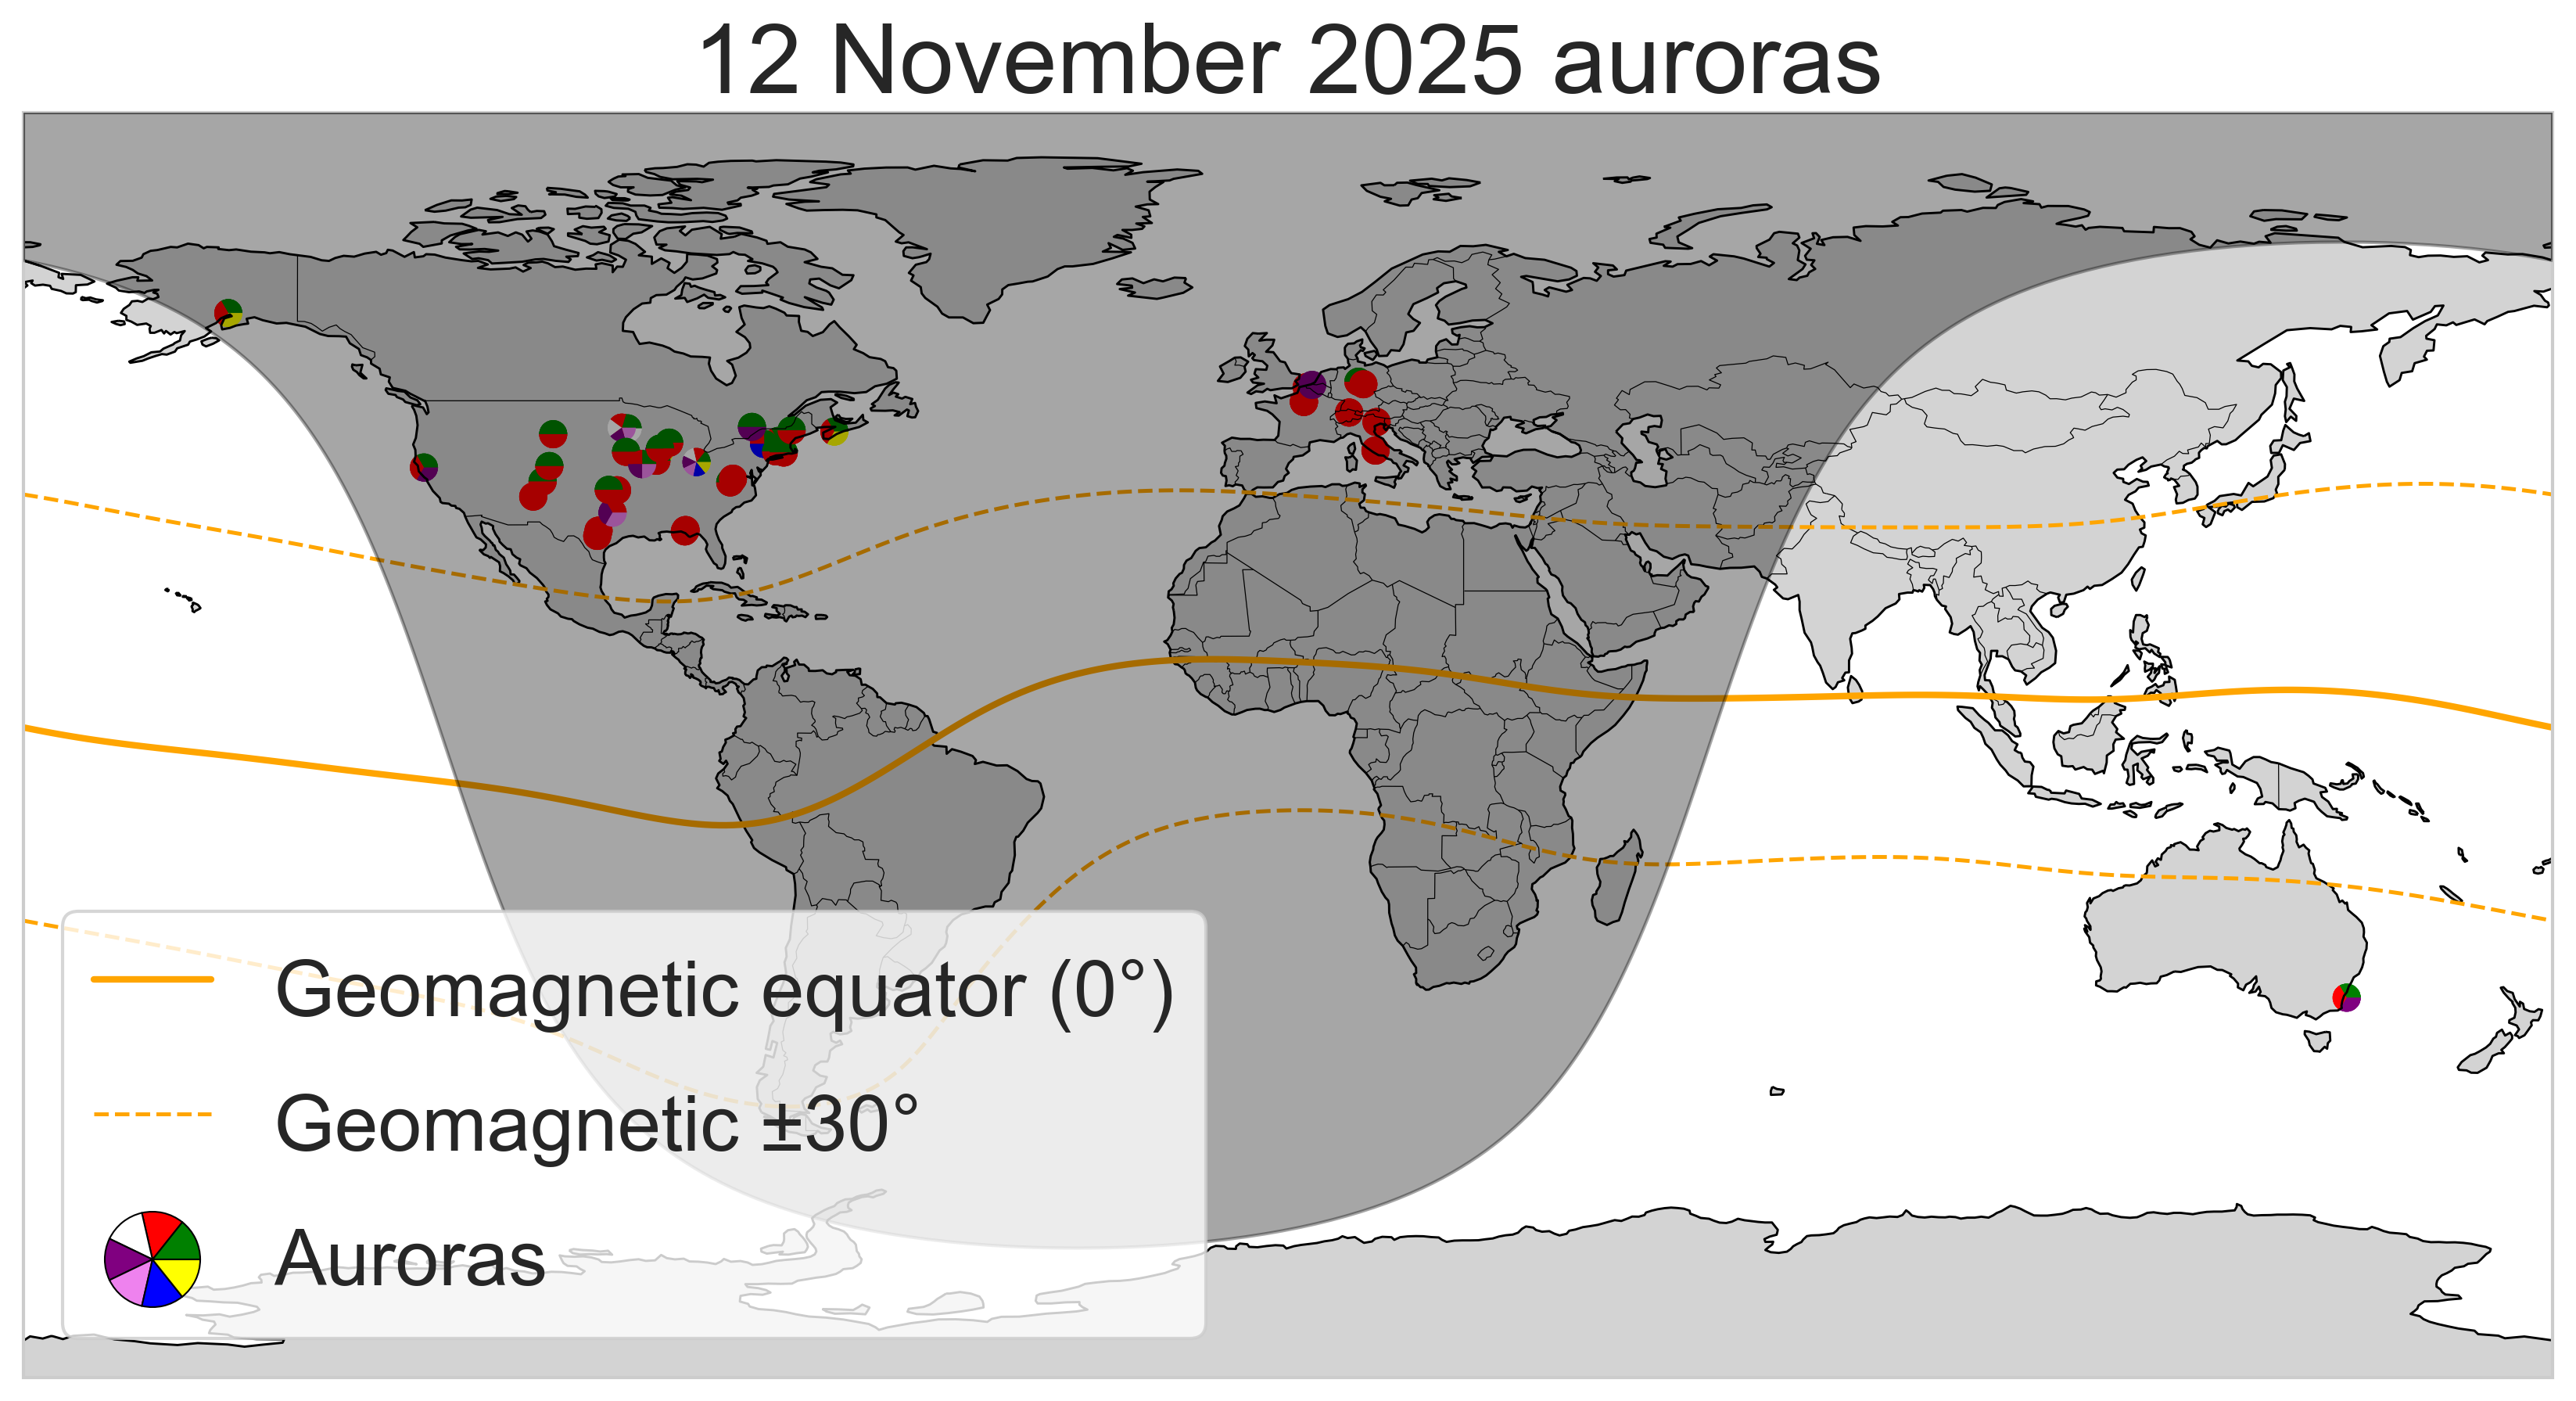

In [19]:
# 3) Plot aurora observations
from datetime import datetime
from app.visualization.aurora_map_plotter import AuroraMapPlotter

plots_dir = base_dir / plots_base_dir / date_str
plots_dir.mkdir(parents=True, exist_ok=True)

save_path = os.path.join(plots_dir, "Observation_map.png")
plotter = AuroraMapPlotter(
    csv_path=csv_path,
    save_path=save_path,
    show_geomagnetic_equator=True,
    show_terminator=True,
)

plotter.plot(
    time=plot_time or datetime(2025, 11, 12, 2, 0),
)


### Run Solar Wind + SYM-H + DST + Kp

In [5]:
# 1) Parameters for space weather indexes plot
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"


In [6]:
# 2) Download and prepare space weather data
from pathlib import Path

from app.pipeline.space_weather_pipeline import prepare_space_weather_data

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
download_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

sw_data = prepare_space_weather_data(date_str=date_str, download_dir=str(download_dir))
print("Space weather datasets prepared.")


Space weather datasets prepared.


Space weather plot saved to: E:\git_reps\Polar-lights\results\2025-11-12


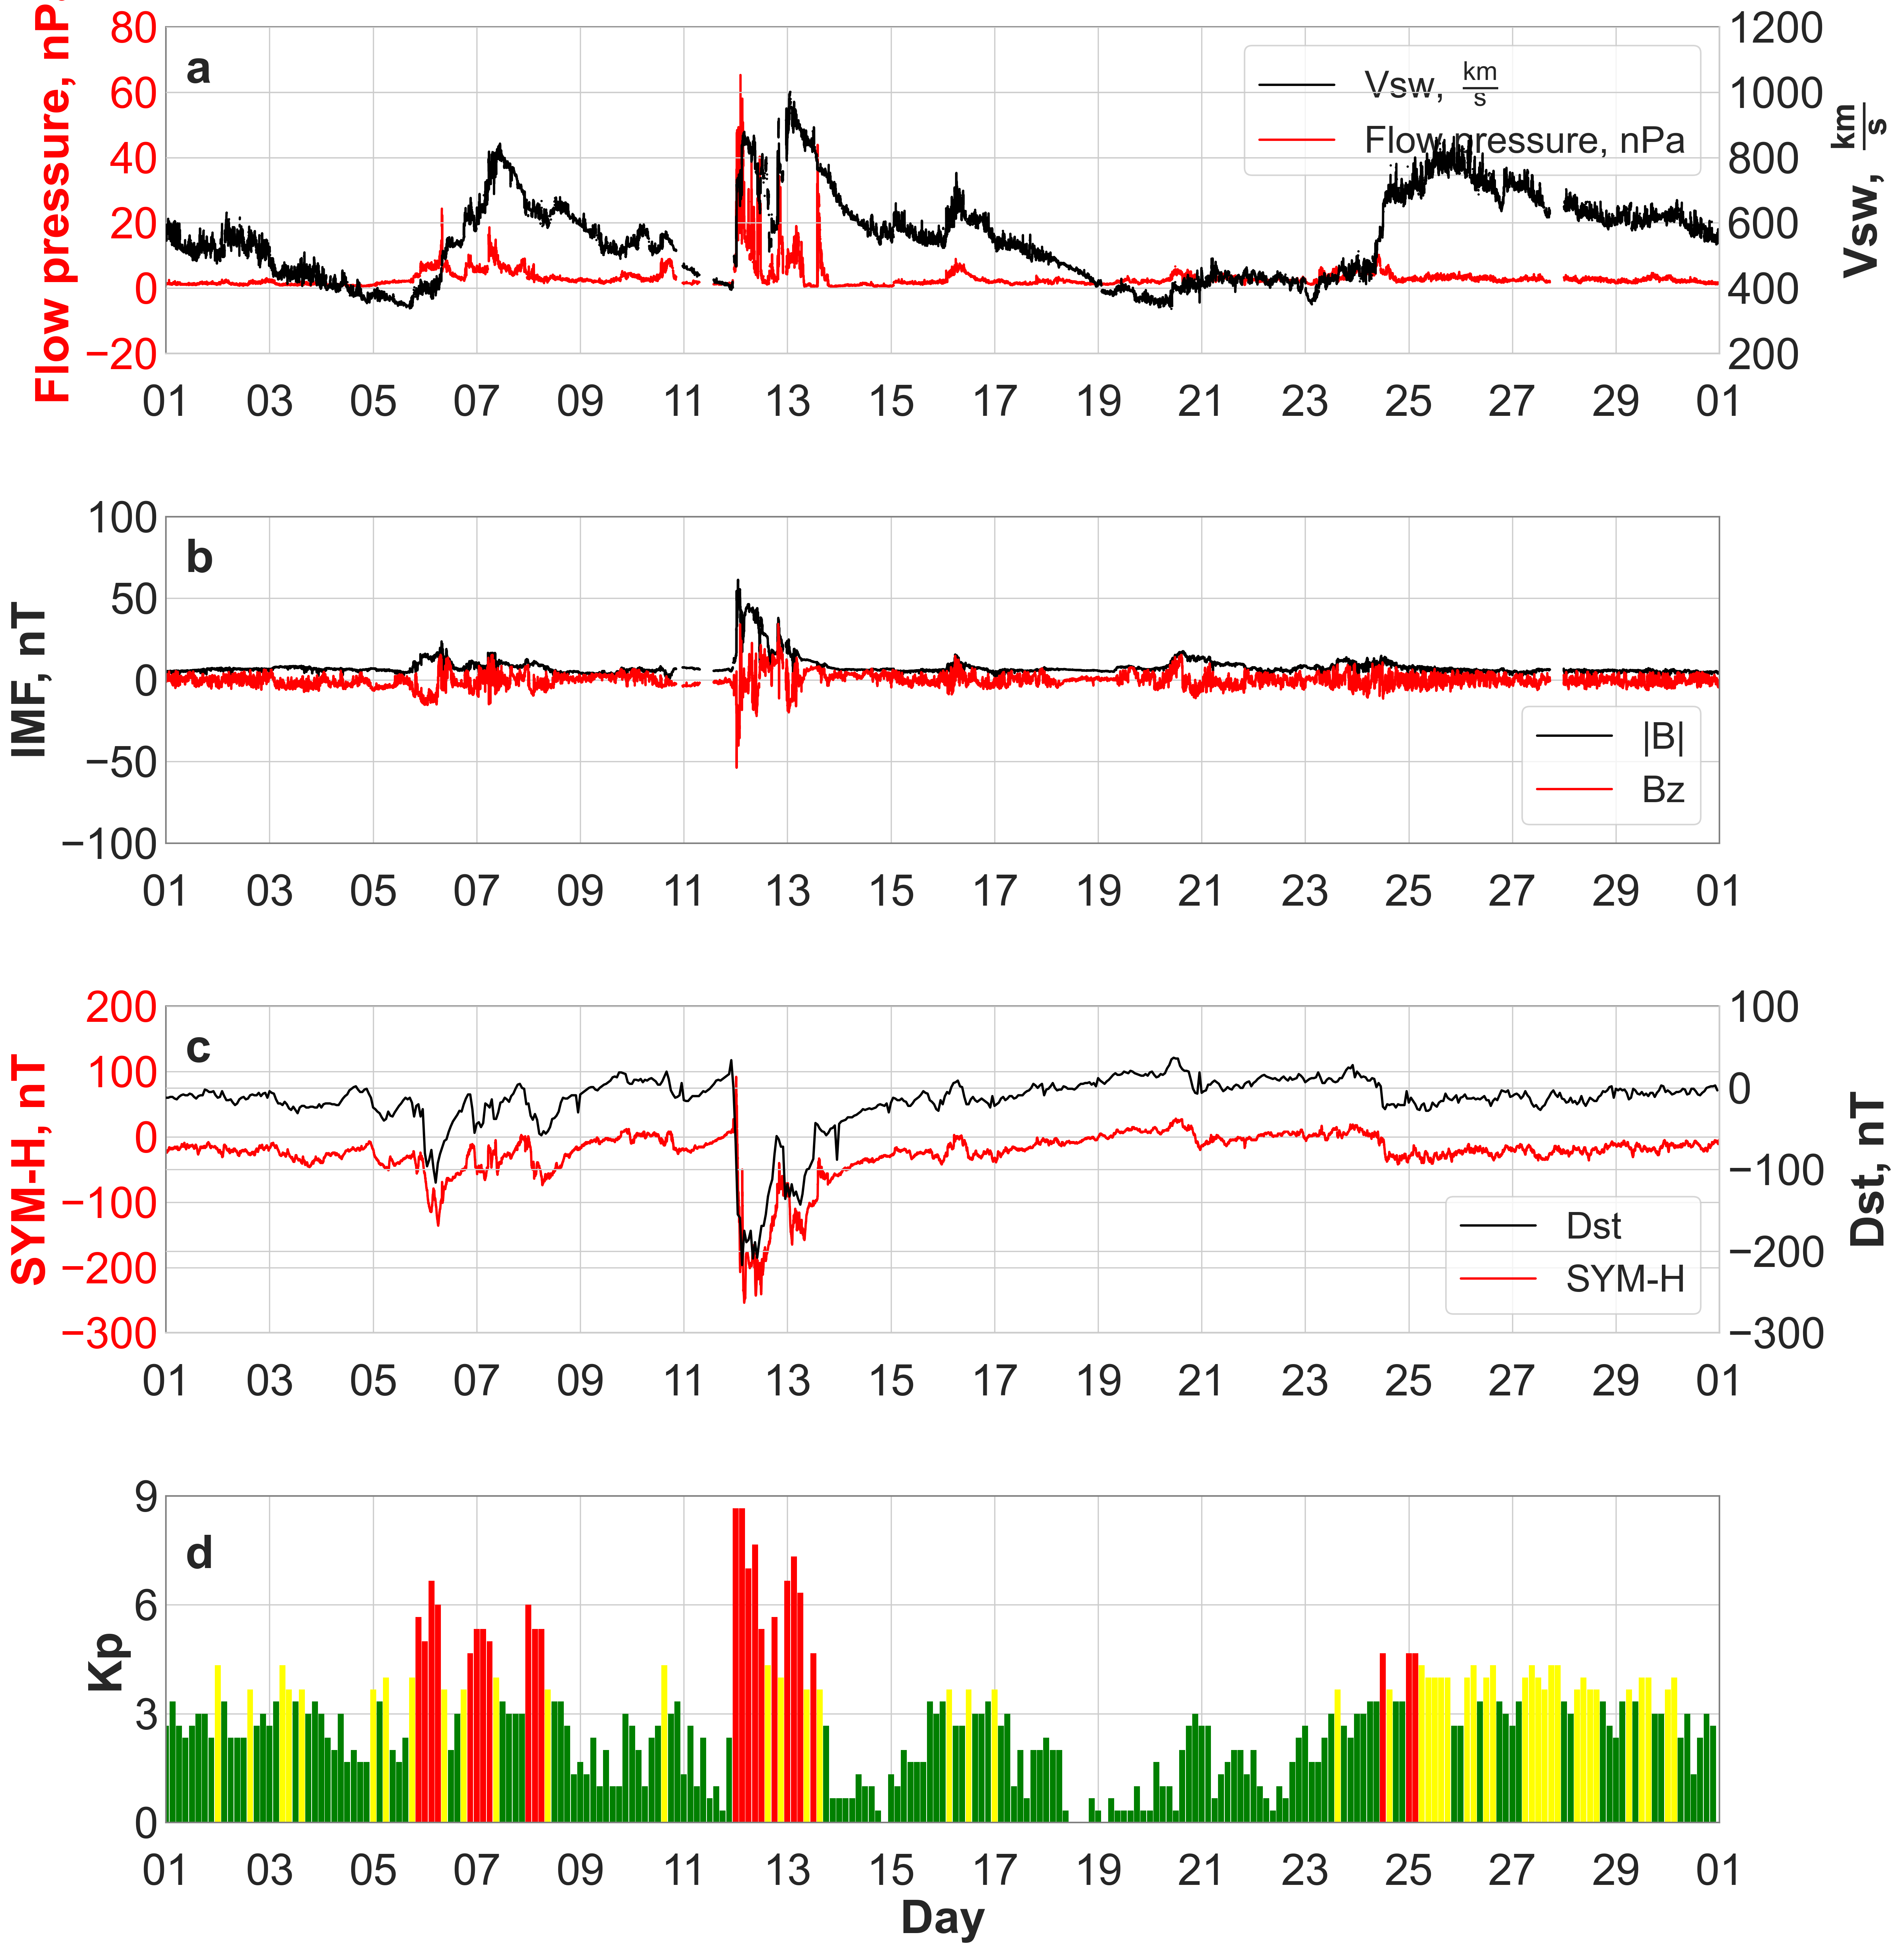

In [7]:
# 3) Plot Solar wind + SYM-H + DST + Kp
from app.visualization.solar_and_indexes_plotter import plot_sw_symh_dst_kp
from IPython.display import display
import matplotlib.pyplot as plt

fig = plot_sw_symh_dst_kp(sw_df=sw_data.omni, dst_df=sw_data.dst, kp_df=sw_data.kp, save_dir=str(plots_dir))
print(f"Space weather plot saved to: {plots_dir.resolve()}")

display(fig)
plt.close(fig)


### Run GIM Maps

In [11]:
# 1) Parameters for GIM maps
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"


In [12]:
# 2) Download GIM data
from pathlib import Path
from datetime import datetime

from app.simurg.gim_downloader import GimDownloader
from app.simurg.gim_processor import GimProcessor

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
gim_dir = download_dir / "gim"
gim_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

GimDownloader(out_dir=str(gim_dir)).download(date_str)
gim_data = GimProcessor(folder_path=str(gim_dir)).load(date_str)
print(f"GIM data points loaded: {len(gim_data)}")


GIM data points loaded: 97


e:\Programming\miniconda\envs\polar_lights\Lib\site-packages\ionex\ionex_file.py:220: UserWarning: Unexpected end of the file <Unknown>.
  warnings.warn(


In [ ]:
# 3) Plot GIM maps
from datetime import datetime
from app.visualization.gim_plotter import plot_gim_maps
from IPython.display import display
import matplotlib.pyplot as plt

def pick_plot_times(data: dict[datetime, object], max_plots: int = 4) -> list[datetime]:
    if not data:
        return []
    sorted_times = sorted(data.keys())
    if len(sorted_times) <= max_plots:
        return sorted_times
    step = max(1, len(sorted_times) // max_plots)
    selected = sorted_times[::step][:max_plots]
    if sorted_times[-1] not in selected:
        selected[-1] = sorted_times[-1]
    return selected

fig = plot_gim_maps(data=gim_data, plot_times=pick_plot_times(gim_data), save_dir=str(plots_dir))
print(f"GIM maps saved to: {plots_dir.resolve()}")

display(fig)
plt.close(fig)


GIM maps saved to: E:\git_reps\Polar-lights\results\2025-11-12


### Run Ionosonde

In [8]:
# 1) Parameters for ionosonde plot
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"
ionosonde_code = None  # optional


In [9]:
# 2) Download ionosonde data
from pathlib import Path

from app.ionosonde.ionosonde_downloader import IonosondeDownloader
from app.ionosonde.ionosonde_processor import IonosondeProcessor

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
ionosonde_dir = download_dir / "ionosonde"
ionosonde_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

IonosondeDownloader(out_dir=str(ionosonde_dir)).download(target_date=date_str, station=ionosonde_code)
ionosonde_df = IonosondeProcessor(folder_path=str(ionosonde_dir)).load(target_date=date_str, station=ionosonde_code)
print(f"Ionosonde rows loaded: {len(ionosonde_df)}")


Ionosonde rows loaded: 131


In [ ]:
# 3) Plot ionosonde
from app.visualization.ionosonde_plotter import plot_ionosonde
from IPython.display import display
import matplotlib.pyplot as plt

fig = plot_ionosonde(ionosonde_df, save_dir=str(plots_dir))
print(f"Ionosonde plot saved to: {plots_dir.resolve()}")

display(fig)
plt.close(fig)


Ionosonde plot saved to: E:\git_reps\Polar-lights\results\2025-11-12


### Run Cosmic Ray Variations

In [3]:
# 1) Parameters for cosmic ray variations plot
date_str = "2025-11-12"
download_base_dir = "files"
plots_base_dir = "results"
cosmic_station_codes = None  # optional


In [4]:
# 2) Download NMDB and Kp data
from pathlib import Path
from datetime import datetime, timedelta

from app.gfz.gfz_downloader import GfzDownloader
from app.gfz.gfz_processor import GfzProcessor
from app.nmdb.nmdb_downloader import NmdbDownloader
from app.nmdb.nmdb_processor import NmdbProcessor

base_dir = Path.cwd().parent
download_dir = base_dir / download_base_dir / date_str
plots_dir = base_dir / plots_base_dir / date_str
nmdb_dir = download_dir / "nmdb"
kp_dir = download_dir / "kp"
nmdb_dir.mkdir(parents=True, exist_ok=True)
kp_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

target_date = datetime.strptime(date_str, "%Y-%m-%d")
start_date = target_date - timedelta(days=15)
end_date = target_date + timedelta(days=15)

NmdbDownloader(out_dir=str(nmdb_dir)).download(start=start_date, end=end_date, stations=cosmic_station_codes)
GfzDownloader(out_dir=str(kp_dir)).download(start_date=start_date, end_date=end_date)

cr_df = NmdbProcessor(folder_path=str(nmdb_dir)).load(date_str)
kp_df = GfzProcessor(folder_path=str(kp_dir)).load(date_str=date_str)
print(f"Cosmic ray rows loaded: {len(cr_df)}")
print(f"Kp rows loaded: {len(kp_df)}")


Cosmic ray rows loaded: 360
Kp rows loaded: 240


Cosmic ray variations plot saved to: E:\git_reps\Polar-lights\results\2025-11-12


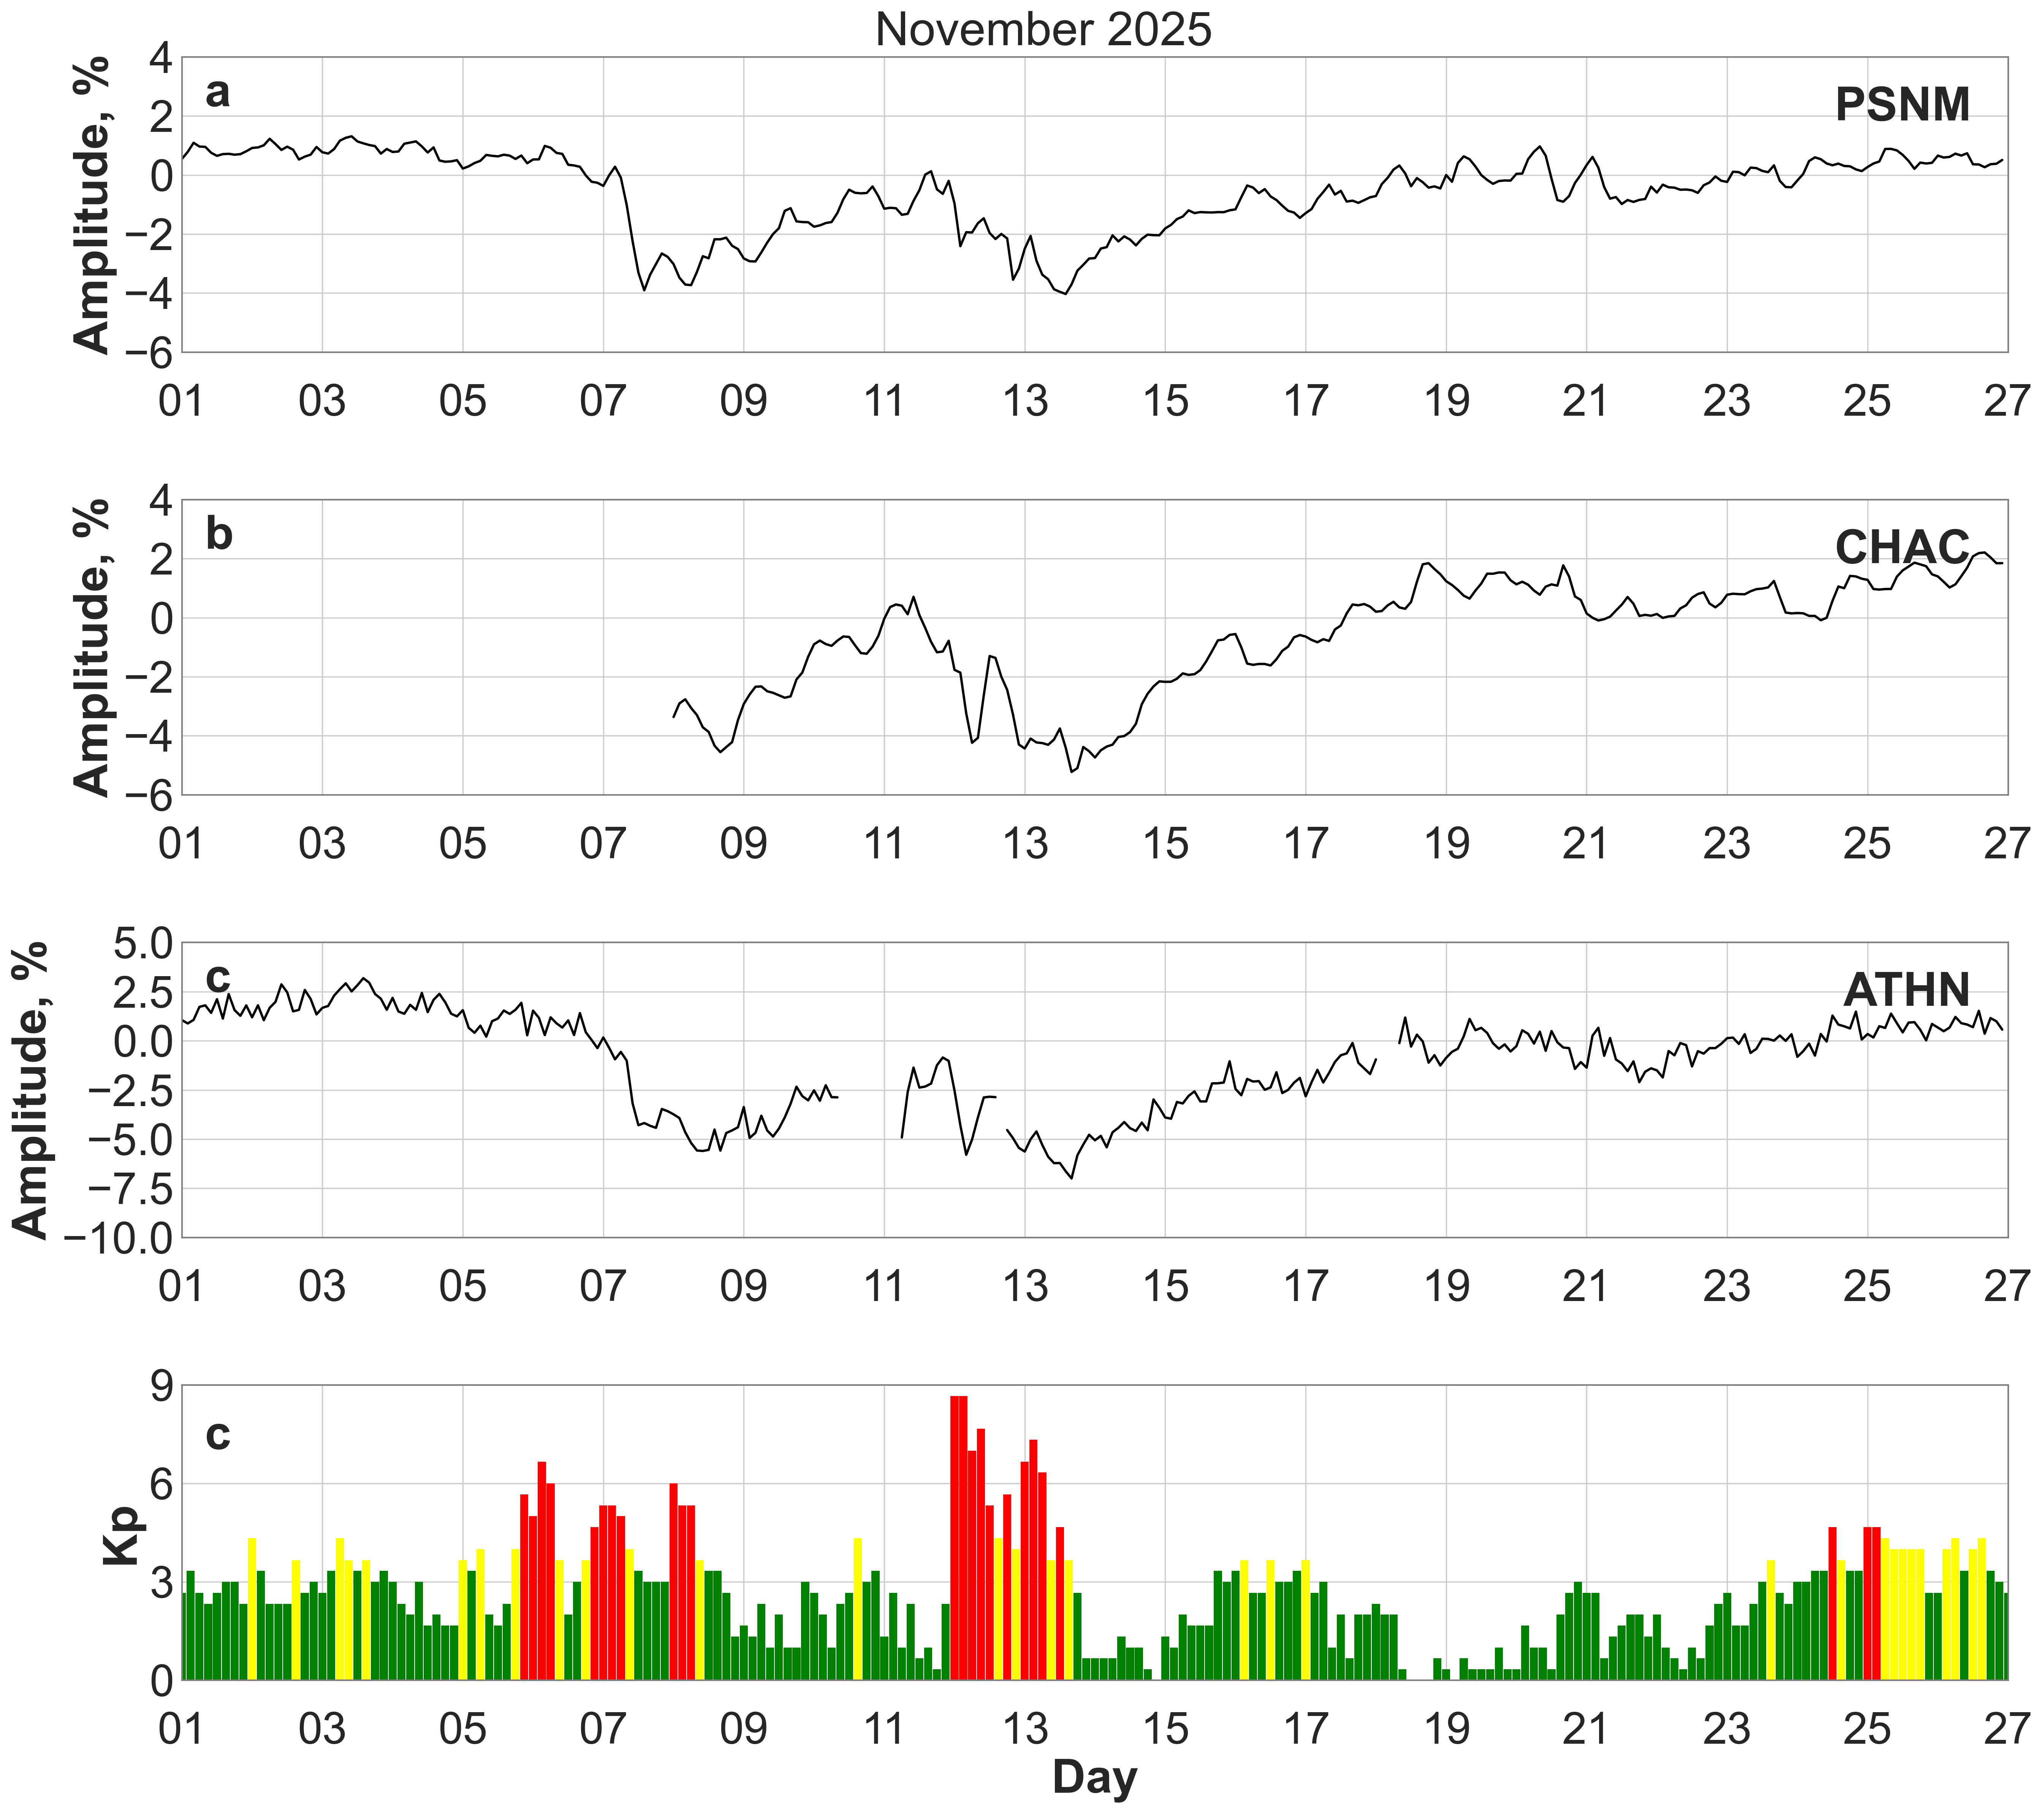

NameError: name 'plt' is not defined

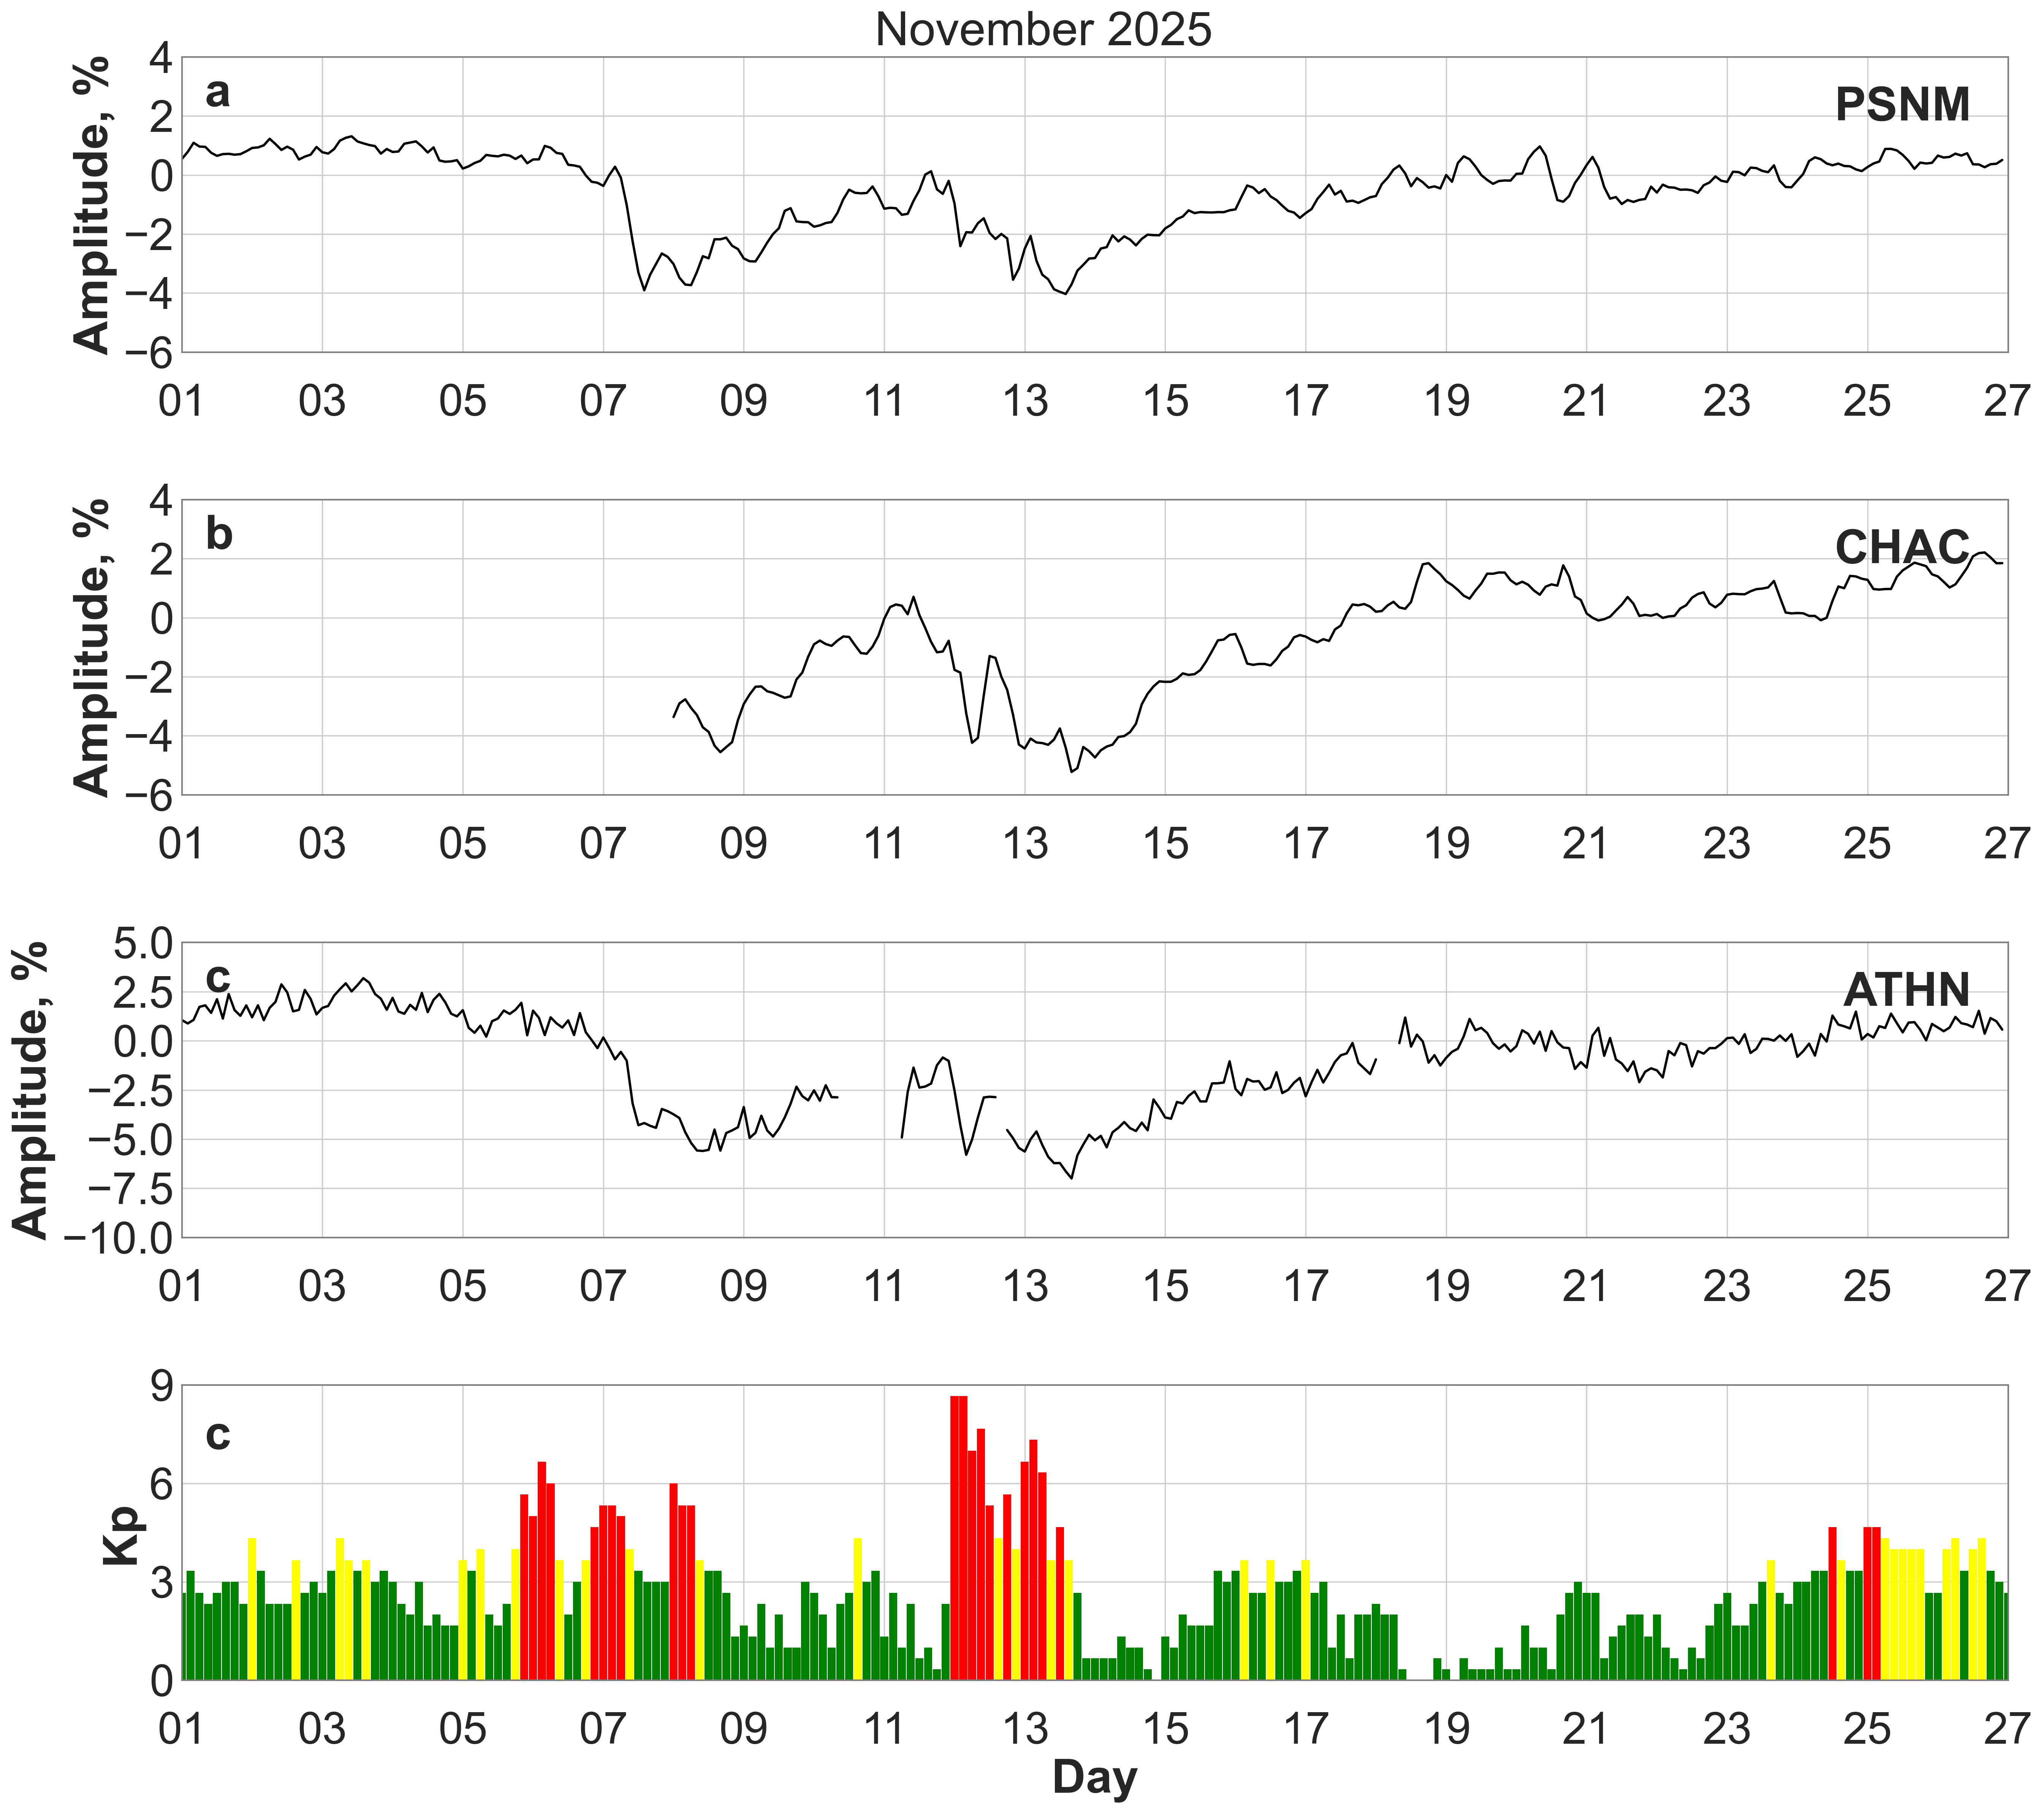

In [ ]:
# 3) Plot cosmic ray variations
from app.pipeline.misc_pipeline import _resolve_cosmic_stations
from app.visualization.cosmic_ray_plotter import plot_cosmic_ray_variations
from IPython.display import display
import matplotlib.pyplot as plt

stations_for_plot = _resolve_cosmic_stations(cr_df, cosmic_station_codes)
fig = plot_cosmic_ray_variations(cr_df=cr_df, kp_df=kp_df, stations=stations_for_plot, save_dir=str(plots_dir))
print(f"Cosmic ray variations plot saved to: {plots_dir.resolve()}")

display(fig)
plt.close(fig)
